# Kalibrasi dan Runtime IndoBERT NLP
Notebook ini menjalankan pipeline IndoBERT-only untuk klasifikasi sentimen. Visualisasi dan evaluasi di notebook dibatasi pada output IndoBERT.


In [1]:
from pathlib import Path
from collections import Counter
import json
import subprocess
import sys

from IPython.display import display
import polars as pl
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.artifact_service import ArtifactService
from services.calibration_service import CalibrationService
from services.evaluation_service import EvaluationService
from services.indobert_inference_service import IndoBERTInferenceService
from services.preprocessing_service import PreprocessingService
from services.source_blacklist_service import SourceBlacklistService

artifact_service = ArtifactService()
PROJECT_ROOT


e:\Software\laragon\bin\python\python-3.13.11-amd64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('E:/School/tugas-akhir/project')

## 1. Konfigurasi Eksekusi


In [2]:
EXPERIMENT_ID = "indobert_nlp_manual"
EXPERIMENT_DIR = Path(config.EXPERIMENT_CONFIG["artifact_root"]) / EXPERIMENT_ID
MODEL_DIR = EXPERIMENT_DIR / "model"
RUNTIME_DIR = EXPERIMENT_DIR / "runtime_indobert"
CALIBRATION_ARTIFACT_PATH = EXPERIMENT_DIR / "calibration_artifact.json"
METRICS_PATH = EXPERIMENT_DIR / "indobert_metrics.json"

RUN_BUILD_TRAINING_DATASET = True
RUN_BUILD_RAW_CANDIDATE_SCHEMA = False
RUN_CREATE_FIXED_SPLIT = True
RUN_TRAIN_MODEL = not (MODEL_DIR / "config.json").exists()
RUN_CALIBRATE_INDOBERT = True
RUN_RUNTIME_INDOBERT = True
RUNTIME_LIMIT = None

print("Experiment dir:", EXPERIMENT_DIR)
print("Model exists:", (MODEL_DIR / "config.json").exists())
print("RUN_TRAIN_MODEL:", RUN_TRAIN_MODEL)
print("RUNTIME_LIMIT:", RUNTIME_LIMIT)


Experiment dir: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual
Model exists: False
RUN_TRAIN_MODEL: True
RUNTIME_LIMIT: None


## 2. Jalankan Tahap Dataset dan Model


In [3]:
stages = [
    (
        "build-training-dataset",
        RUN_BUILD_TRAINING_DATASET,
        [sys.executable, "main.py", "build-training-dataset"],
    ),
    (
        "build-raw-candidate-schema",
        RUN_BUILD_RAW_CANDIDATE_SCHEMA,
        [sys.executable, "main.py", "build-raw-candidate-schema"],
    ),
    (
        "create-fixed-group-split",
        RUN_CREATE_FIXED_SPLIT,
        [sys.executable, "main.py", "create-fixed-group-split"],
    ),
    (
        "train-indobert",
        RUN_TRAIN_MODEL,
        [sys.executable, "main.py", "train-indobert", "--experiment-id", EXPERIMENT_ID],
    ),
]

completed_stages = []
for stage_name, enabled, command in tqdm(stages, desc="Pipeline IndoBERT NLP", unit="stage"):
    if not enabled:
        tqdm.write(f"SKIP {stage_name}")
        completed_stages.append({"stage": stage_name, "status": "skipped"})
        continue

    tqdm.write(f"RUN  {stage_name}")
    tqdm.write(" ".join(str(part) for part in command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    completed_stages.append({"stage": stage_name, "status": "done"})

completed_stages


Pipeline IndoBERT NLP:   0%|          | 0/4 [00:00<?, ?stage/s]

RUN  build-training-dataset
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py build-training-dataset


Pipeline IndoBERT NLP:  25%|██▌       | 1/4 [00:00<00:01,  2.11stage/s]

SKIP build-raw-candidate-schema
RUN  create-fixed-group-split
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py create-fixed-group-split


Pipeline IndoBERT NLP:  75%|███████▌  | 3/4 [00:03<00:01,  1.27s/stage]

RUN  train-indobert
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py train-indobert --experiment-id indobert_nlp_manual


Pipeline IndoBERT NLP: 100%|██████████| 4/4 [14:15<00:00, 213.78s/stage]


[{'stage': 'build-training-dataset', 'status': 'done'},
 {'stage': 'build-raw-candidate-schema', 'status': 'skipped'},
 {'stage': 'create-fixed-group-split', 'status': 'done'},
 {'stage': 'train-indobert', 'status': 'done'}]

## 3. Kalibrasi Confidence IndoBERT


In [4]:
LOGIT_COLUMNS = ("bert_logit_negatif", "bert_logit_netral", "bert_logit_positif")
PROBABILITY_COLUMNS = ("bert_prob_negatif", "bert_prob_netral", "bert_prob_positif")


def apply_calibrated_probabilities(df: pl.DataFrame, *, temperature: float) -> pl.DataFrame:
    calibrator = CalibrationService()
    logits = [[float(value) for value in row] for row in df.select(LOGIT_COLUMNS).rows()]
    probabilities = calibrator.apply_temperature(logits, temperature)
    rows = []
    for probs in probabilities:
        label_id = max(range(len(probs)), key=lambda index: probs[index])
        sorted_probs = sorted(probs, reverse=True)
        rows.append(
            {
                "bert_label": config.ID2LABEL[label_id],
                "bert_label_id": label_id,
                "bert_prob_negatif": float(probs[0]),
                "bert_prob_netral": float(probs[1]),
                "bert_prob_positif": float(probs[2]),
                "bert_confidence": float(sorted_probs[0]),
                "bert_margin": float(sorted_probs[0] - sorted_probs[1]),
                "bert_entropy": IndoBERTInferenceService._normalized_entropy(probs),
                "bert_temperature": temperature,
            }
        )
    replacement = pl.DataFrame(rows)
    drop_columns = [column for column in replacement.columns if column in df.columns]
    return df.drop(drop_columns).hstack(replacement)


def predict_indobert(
    df: pl.DataFrame,
    *,
    inference: IndoBERTInferenceService,
    temperature: float,
) -> pl.DataFrame:
    predicted = inference.predict_dataframe(df, text_column=config.COL_PROCESSED)
    return apply_calibrated_probabilities(predicted, temperature=temperature)


def evaluate_indobert(df: pl.DataFrame, *, actual_column: str = "sentiment_label") -> dict[str, object]:
    probabilities = df.select(PROBABILITY_COLUMNS).rows()
    return EvaluationService().evaluate_predictions(
        df[actual_column].to_list(),
        df["bert_label"].to_list(),
        probabilities=probabilities,
    )


calibration_artifact = None
metrics = None
if RUN_CALIBRATE_INDOBERT:
    if not (MODEL_DIR / "config.json").exists():
        raise FileNotFoundError(f"Model IndoBERT belum tersedia: {MODEL_DIR}")

    split_df = pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH)
    calibration_df = split_df.filter(pl.col("split") == "calibration")
    test_df = split_df.filter(pl.col("split") == "test")
    golden_non_train_df = split_df.filter(pl.col("split").is_in(["calibration", "test"]))

    if calibration_df.is_empty() or test_df.is_empty():
        raise ValueError("Calibration dan test split wajib tersedia")

    inference = IndoBERTInferenceService(model_path=MODEL_DIR)
    uncalibrated_calibration = inference.predict_dataframe(
        calibration_df,
        text_column=config.COL_PROCESSED,
    )
    calibration_artifact = CalibrationService().fit_from_dataframe(
        uncalibrated_calibration,
        label_column="label_id",
        group_column="group_id",
    )
    artifact_service.save_json(calibration_artifact, CALIBRATION_ARTIFACT_PATH)

    temperature = float(calibration_artifact["temperature"])
    calibrated_calibration = apply_calibrated_probabilities(
        uncalibrated_calibration,
        temperature=temperature,
    )
    test_predictions = predict_indobert(
        test_df,
        inference=inference,
        temperature=temperature,
    )
    golden_non_train_predictions = predict_indobert(
        golden_non_train_df,
        inference=inference,
        temperature=temperature,
    )
    golden_all_predictions = predict_indobert(
        split_df,
        inference=inference,
        temperature=temperature,
    )

    metrics = {
        "calibration_indobert": evaluate_indobert(calibrated_calibration),
        "test_indobert": evaluate_indobert(test_predictions),
        "golden_non_train_indobert": evaluate_indobert(golden_non_train_predictions),
        "golden_all_indobert": evaluate_indobert(golden_all_predictions),
    }
    artifact_service.save_parquet(
        calibrated_calibration,
        EXPERIMENT_DIR / "indobert_calibration_predictions.parquet",
    )
    artifact_service.save_parquet(
        test_predictions,
        EXPERIMENT_DIR / "indobert_test_predictions.parquet",
    )
    artifact_service.save_parquet(
        golden_non_train_predictions,
        EXPERIMENT_DIR / "indobert_golden_non_train_predictions.parquet",
    )
    artifact_service.save_parquet(
        golden_all_predictions,
        EXPERIMENT_DIR / "indobert_golden_all_predictions.parquet",
    )
    artifact_service.save_json(metrics, METRICS_PATH)

    print(f"Calibration artifact: {CALIBRATION_ARTIFACT_PATH}")
    print(f"Metrics: {METRICS_PATH}")
else:
    print("SKIP IndoBERT calibration")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3530.09it/s]


Calibration artifact: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\calibration_artifact.json
Metrics: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\indobert_metrics.json


## 4. Runtime IndoBERT NLP


In [5]:
INDOBERT_RUNTIME_REQUIRED_COLUMNS = (
    "text_id",
    "text",
    "source_url",
    "source_type",
    "location",
)
INDOBERT_PREDICTIONS_PATH = RUNTIME_DIR / "indobert_nlp_predictions.parquet"
INDOBERT_PREDICTIONS_CSV_PATH = RUNTIME_DIR / "indobert_nlp_predictions.csv"
INDOBERT_RUNTIME_SUMMARY_PATH = RUNTIME_DIR / "indobert_nlp_summary.json"


def validate_indobert_runtime_input(df: pl.DataFrame) -> None:
    missing = [column for column in INDOBERT_RUNTIME_REQUIRED_COLUMNS if column not in df.columns]
    if missing:
        raise KeyError(f"Kolom runtime wajib hilang: {missing}")


def prepare_indobert_runtime_input(df: pl.DataFrame) -> pl.DataFrame:
    if df.is_empty():
        return df

    source_service = SourceBlacklistService.from_paths()
    preprocessing = PreprocessingService()
    rows = []
    for row in df.iter_rows(named=True):
        text = str(row.get("text") or "")
        processed = preprocessing.process(text)["processed_text"]
        source_url = str(row.get("source_url") or "")
        normalized_source_url = str(row.get("normalized_source_url") or "")
        if not normalized_source_url:
            normalized_source_url = source_service.normalize_url(source_url)
        rows.append(
            {
                **row,
                "original_text": text,
                config.COL_PROCESSED: processed,
                "normalized_source_url": normalized_source_url,
                "_dedupe_key": f"{normalized_source_url}::{processed}",
            }
        )

    prepared = pl.from_dicts(rows, strict=False)
    prepared = prepared.filter(pl.col(config.COL_PROCESSED).str.strip_chars().str.len_chars() > 0)
    return prepared.unique(subset=["_dedupe_key"], keep="first", maintain_order=True).drop("_dedupe_key")


def order_indobert_output_columns(df: pl.DataFrame) -> pl.DataFrame:
    preferred = [
        "text_id",
        "original_text",
        config.COL_PROCESSED,
        "bert_label",
        "indobert_sentiment",
        "bert_prob_negatif",
        "bert_prob_netral",
        "bert_prob_positif",
        "bert_confidence",
        "bert_margin",
        "bert_entropy",
        "bert_temperature",
        "source_url",
        "source_type",
        "location",
        "aspect",
        "dataset_tier",
        "inclusion_status",
        "raw_source_file",
        "raw_domain",
        "content_status",
        "query_group",
        "query",
        "normalized_source_url",
    ]
    ordered = [column for column in preferred if column in df.columns]
    extras = [column for column in df.columns if column not in ordered]
    return df.select(ordered + extras)


def build_indobert_summary(
    *,
    input_df: pl.DataFrame,
    prepared_df: pl.DataFrame,
    result_df: pl.DataFrame,
    input_path: Path,
    total_input_rows: int,
    runtime_limit: int | None,
) -> dict[str, object]:
    labels = result_df["indobert_sentiment"].to_list() if "indobert_sentiment" in result_df.columns else []
    invalid_labels = sorted(set(labels) - set(config.SENTIMENT_LABELS))
    empty_sentiment_rows = result_df.filter(
        pl.col("indobert_sentiment").is_null()
        | (pl.col("indobert_sentiment").str.strip_chars().str.len_chars() == 0)
    ).height
    gates = {
        "all_runtime_rows_have_indobert_sentiment": empty_sentiment_rows == 0,
        "all_labels_valid": not invalid_labels,
    }
    return {
        "input_path": str(input_path),
        "model_dir": str(MODEL_DIR),
        "calibration_artifact_path": str(CALIBRATION_ARTIFACT_PATH),
        "total_input_rows": total_input_rows,
        "runtime_limit": runtime_limit,
        "input_rows": input_df.height,
        "deduplicated_rows": prepared_df.height,
        "output_rows": result_df.height,
        "indobert_sentiment_distribution": dict(Counter(labels)),
        "invalid_labels": invalid_labels,
        "gates": gates,
        "all_gates_passed": all(gates.values()),
    }


runtime_summary = None
if RUN_RUNTIME_INDOBERT:
    if not CALIBRATION_ARTIFACT_PATH.exists():
        raise FileNotFoundError(f"Calibration artifact belum tersedia: {CALIBRATION_ARTIFACT_PATH}")
    if not config.RAW_CANDIDATE_SCHEMA_PATH.exists():
        raise FileNotFoundError(f"Raw candidate schema belum tersedia: {config.RAW_CANDIDATE_SCHEMA_PATH}")

    runtime_input_df = pl.read_csv(
        config.RAW_CANDIDATE_SCHEMA_PATH,
        infer_schema_length=10_000,
        ignore_errors=True,
    )
    total_input_rows = runtime_input_df.height
    if RUNTIME_LIMIT is not None:
        if RUNTIME_LIMIT <= 0:
            raise ValueError("RUNTIME_LIMIT harus lebih besar dari 0")
        runtime_input_df = runtime_input_df.head(RUNTIME_LIMIT)

    validate_indobert_runtime_input(runtime_input_df)
    prepared_runtime_df = prepare_indobert_runtime_input(runtime_input_df)
    runtime_inference = IndoBERTInferenceService(
        model_path=MODEL_DIR,
        calibration_artifact_path=CALIBRATION_ARTIFACT_PATH,
    )
    runtime_predictions_df = runtime_inference.predict_dataframe(
        prepared_runtime_df,
        text_column=config.COL_PROCESSED,
    )
    indobert_result_df = order_indobert_output_columns(
        runtime_predictions_df.with_columns(
            pl.col("bert_label").alias("indobert_sentiment")
        )
    )
    runtime_summary = build_indobert_summary(
        input_df=runtime_input_df,
        prepared_df=prepared_runtime_df,
        result_df=indobert_result_df,
        input_path=config.RAW_CANDIDATE_SCHEMA_PATH,
        total_input_rows=total_input_rows,
        runtime_limit=RUNTIME_LIMIT,
    )

    artifact_service.save_parquet(indobert_result_df, INDOBERT_PREDICTIONS_PATH)
    artifact_service.save_csv(indobert_result_df, INDOBERT_PREDICTIONS_CSV_PATH)
    artifact_service.save_json(runtime_summary, INDOBERT_RUNTIME_SUMMARY_PATH)
    artifact_service.save_json(
        {
            "input_path": str(config.RAW_CANDIDATE_SCHEMA_PATH),
            "model_dir": str(MODEL_DIR),
            "calibration_artifact_path": str(CALIBRATION_ARTIFACT_PATH),
            "output_dir": str(RUNTIME_DIR),
            "runtime_limit": RUNTIME_LIMIT,
            "label_mapping": config.LABEL2ID,
        },
        RUNTIME_DIR / "indobert_nlp_manifest.json",
    )
    print(f"Predictions: {INDOBERT_PREDICTIONS_PATH}")
    print(f"Summary: {INDOBERT_RUNTIME_SUMMARY_PATH}")
else:
    print("SKIP runtime-indobert")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7256.21it/s]


Predictions: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_indobert\indobert_nlp_predictions.parquet
Summary: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_indobert\indobert_nlp_summary.json


## 5. Cek Artifact Utama


In [6]:
artifact_paths = {
    "training_dataset": config.TRAINING_DATASET_PATH,
    "training_dataset_with_split": config.TRAINING_DATASET_WITH_SPLIT_PATH,
    "training_manifest": config.ARTIFACTS / "training_dataset_manifest.json",
    "split_manifest": config.FIXED_SPLIT_MANIFEST_PATH,
    "model_dir": MODEL_DIR,
    "model_manifest": EXPERIMENT_DIR / "model_manifest.json",
    "calibration_artifact": CALIBRATION_ARTIFACT_PATH,
    "indobert_metrics": METRICS_PATH,
    "runtime_predictions_parquet": INDOBERT_PREDICTIONS_PATH,
    "runtime_predictions_csv": INDOBERT_PREDICTIONS_CSV_PATH,
    "golden_non_train_predictions": EXPERIMENT_DIR / "indobert_golden_non_train_predictions.parquet",
    "golden_all_predictions": EXPERIMENT_DIR / "indobert_golden_all_predictions.parquet",
    "runtime_summary": INDOBERT_RUNTIME_SUMMARY_PATH,
}

artifact_df = pl.DataFrame(
    [
        {"artifact": name, "path": str(path), "exists": Path(path).exists()}
        for name, path in artifact_paths.items()
    ]
)
display(artifact_df)


artifact,path,exists
str,str,bool
"""training_dataset""","""E:\School\tugas-akhir\project\…",true
"""training_dataset_with_split""","""E:\School\tugas-akhir\project\…",true
"""training_manifest""","""E:\School\tugas-akhir\project\…",true
"""split_manifest""","""E:\School\tugas-akhir\project\…",true
"""model_dir""","""E:\School\tugas-akhir\project\…",true
…,…,…
"""runtime_predictions_parquet""","""E:\School\tugas-akhir\project\…",true
"""runtime_predictions_csv""","""E:\School\tugas-akhir\project\…",true
"""golden_non_train_predictions""","""E:\School\tugas-akhir\project\…",true


## 6. Manifest, Calibration, dan Metrics


In [7]:
def load_json_if_exists(path: Path):
    if not path.exists():
        print(f"Belum ada: {path}")
        return None
    return json.loads(path.read_text(encoding=config.ENCODING))


training_manifest = load_json_if_exists(config.ARTIFACTS / "training_dataset_manifest.json")
split_manifest = load_json_if_exists(config.FIXED_SPLIT_MANIFEST_PATH)
calibration_artifact = load_json_if_exists(CALIBRATION_ARTIFACT_PATH)
metrics = load_json_if_exists(METRICS_PATH)
runtime_summary = load_json_if_exists(INDOBERT_RUNTIME_SUMMARY_PATH)


## 7. Preview Output Runtime IndoBERT


In [8]:
if INDOBERT_PREDICTIONS_PATH.exists():
    predictions_df = pl.read_parquet(INDOBERT_PREDICTIONS_PATH)
    display(predictions_df.head(20))

    if "indobert_sentiment" in predictions_df.columns:
        display(
            predictions_df
            .group_by("indobert_sentiment")
            .len()
            .sort("indobert_sentiment")
        )
else:
    print("Runtime predictions belum tersedia:", INDOBERT_PREDICTIONS_PATH)


text_id,original_text,processed_text,bert_label,indobert_sentiment,bert_prob_negatif,bert_prob_netral,bert_prob_positif,bert_confidence,bert_margin,bert_entropy,bert_temperature,source_url,source_type,location,aspect,dataset_tier,inclusion_status,raw_source_file,raw_domain,content_status,query_group,query,normalized_source_url,text,subjectivity_type,speaker_type,public_opinion_scope,corpus_role,sentiment_label,label_status,source_id,verification_status,evidence_support_score,parent_text_id,decision_note,raw_title,raw_text_length,location_source,location_match,is_specific_location,blacklist_status,blacklist_reason_codes,blacklist_is_excluded,base_text_id,sentence_index,sentence_count,candidate_generation_method,source_text_length,candidate_text_length,bert_label_id,bert_logit_negatif,bert_logit_netral,bert_logit_positif
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,i64,str,str,bool,str,str,bool,str,i64,i64,str,i64,i64,i64,f64,f64,f64
"""RAW-0003#01""","""OIS POWER on Instagram: ""#PLTS…","""ois power on instagram pembang…","""netral""","""netral""",0.109892,0.829377,0.060731,0.829377,0.719485,0.516975,2.018316,"""https://www.instagram.com/reel…","""social_media""","""Sambas""","""general_shs""","""B_review_queue""","""review_required_before_core""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""https://instagram.com/reel/DY0…","""OIS POWER on Instagram: ""#PLTS…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""""","""unlabeled""","""RAW-SRC-0003""","""perlu_verifikasi""",0.9,"""RAW-0003""","""social_domain_review""","""OIS POWER | #PLTS #PanelSurya …",371,"""query""","""sambas""",true,"""clear""","""[]""",false,"""RAW-0003""",1,2,"""sentence_split""",311,132,1,-1.067125,3.012245,-2.264094
"""RAW-0003#02""","""Instagram · ois_power 6 suka ·…","""instagram ois power 6 suka 1 b…","""netral""","""netral""",0.101464,0.842259,0.056277,0.842259,0.740796,0.490326,2.018316,"""https://www.instagram.com/reel…","""social_media""","""Sambas""","""general_shs""","""B_review_queue""","""review_required_before_core""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""https://instagram.com/reel/DY0…","""Instagram · ois_power 6 suka ·…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""""","""unlabeled""","""RAW-SRC-0003""","""perlu_verifikasi""",0.9,"""RAW-0003""","""social_domain_review""","""OIS POWER | #PLTS #PanelSurya …",371,"""query""","""sambas""",true,"""clear""","""[]""",false,"""RAW-0003""",2,2,"""sentence_split""",311,178,1,-1.181118,3.090415,-2.370763
"""RAW-0004#01""","""TEKNIK LISTRIK on Instagram: ""…","""teknik listrik on instagram pa…","""netral""","""netral""",0.112831,0.803873,0.083295,0.803873,0.691042,0.572265,2.018316,"""https://www.instagram.com/p/DR…","""social_media""","""Sambas""","""general_shs""","""B_review_queue""","""review_required_before_core""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""https://instagram.com/p/DRq794…","""TEKNIK LISTRIK on Instagram: ""…","""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""""","""unlabeled""","""RAW-SRC-0004""","""perlu_verifikasi""",0.9,"""RAW-0004""","""social_domain_review""","""Panel Surya Listrik (Fotovolta…",792,"""query""","""sambas""",true,"""clear""","""[]""",false,"""RAW-0004""",1,5,"""sentence_split""",768,276,1,-1.024943,2.938118,-1.637504
"""RAW-0004#02""","""#panelsurya #energi #sollarcel…","""panelsurya energi sollarcell p…","""netral""","""netral""",0.077918,0.781107,0.140975,0.781107,0.640132,0.608054,2.018316,"""https://www.instagram.com/p/DR…","""social_media""","""Samb

indobert_sentiment,len
str,u32
"""negatif""",3420
"""netral""",5642
"""positif""",7405


## 8. Helper Visualisasi


In [9]:
import matplotlib.pyplot as plt

LABEL_ORDER = ["negatif", "netral", "positif"]


def counts_from_series(values):
    counts = {}
    for value in values:
        key = str(value)
        counts[key] = counts.get(key, 0) + 1
    return counts


def plot_count_bar(ax, counts, title, xlabel="Kategori", ylabel="Jumlah", order=None):
    labels = list(order or counts.keys())
    values = [counts.get(label, 0) for label in labels]
    ax.bar(labels, values, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    for index, value in enumerate(values):
        ax.text(index, value, str(value), ha="center", va="bottom", fontsize=9)


def plot_confusion_matrix(ax, matrix, title):
    values = [
        [int(matrix.get(actual, {}).get(predicted, 0)) for predicted in LABEL_ORDER]
        for actual in LABEL_ORDER
    ]
    image = ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=25, ha="right")
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    threshold = max([item for row in values for item in row] or [0]) / 2
    for row_index, row in enumerate(values):
        for col_index, value in enumerate(row):
            color = "white" if value > threshold else "black"
            ax.text(col_index, row_index, str(value), ha="center", va="center", color=color)
    return image


## 9. Confusion Matrix Golden dan Performa IndoBERT


Confusion matrix memakai golden_all_indobert agar sebaran lebih besar. Metrik final tetap mengacu pada test_indobert.


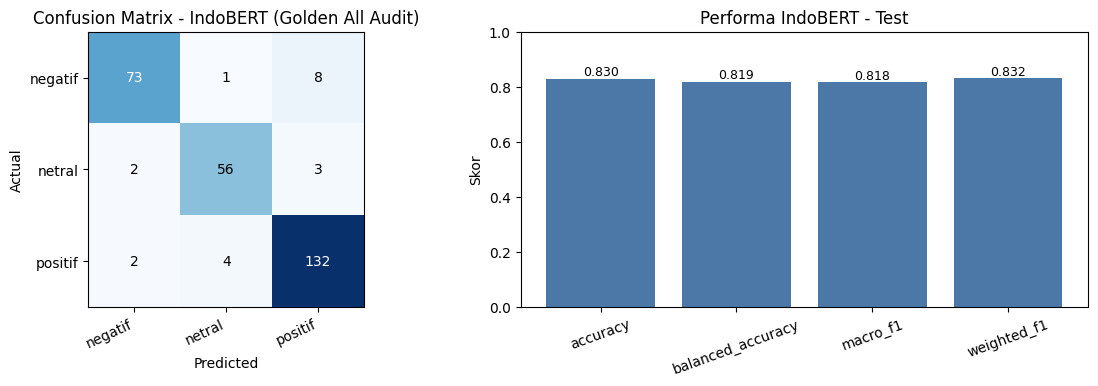

In [10]:
if metrics is None or "test_indobert" not in metrics:
    print("indobert_metrics.json belum tersedia. Jalankan tahap kalibrasi IndoBERT lebih dulu.")
else:
    test_metrics = metrics["test_indobert"]
    matrix_key = "golden_all_indobert" if "golden_all_indobert" in metrics else "test_indobert"
    matrix_metrics = metrics[matrix_key]
    matrix_title_suffix = "Golden All Audit" if matrix_key == "golden_all_indobert" else "Test"

    if matrix_key == "golden_all_indobert":
        print(
            "Confusion matrix memakai golden_all_indobert agar sebaran lebih besar. "
            "Metrik final tetap mengacu pada test_indobert."
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_confusion_matrix(
        axes[0],
        matrix_metrics["confusion_matrix"],
        f"Confusion Matrix - IndoBERT ({matrix_title_suffix})",
    )

    metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
    axes[1].bar(
        metric_names,
        [float(test_metrics[name]) for name in metric_names],
        color="#4c78a8",
    )
    axes[1].set_title("Performa IndoBERT - Test")
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Skor")
    axes[1].tick_params(axis="x", rotation=20)
    for index, name in enumerate(metric_names):
        value = float(test_metrics[name])
        axes[1].text(index, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout(pad=1.2)
    plt.show()


## 10. Visualisasi Akurasi IndoBERT
Visualisasi ini membandingkan accuracy dan balanced accuracy dari metrics IndoBERT yang tersedia.


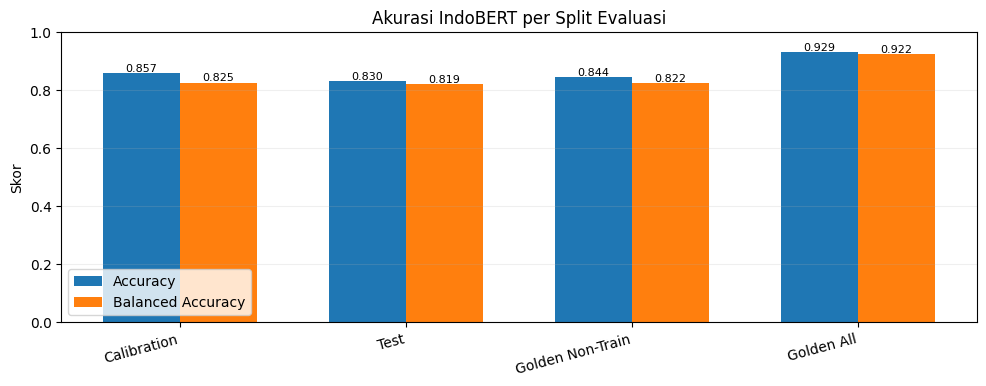

scope,accuracy,balanced_accuracy,macro_f1,weighted_f1
str,f64,f64,f64,f64
"""Calibration""",0.8571,0.8248,0.8494,0.8552
"""Test""",0.8298,0.819,0.8176,0.8316
"""Golden Non-Train""",0.8438,0.8223,0.8318,0.843
"""Golden All""",0.9288,0.9216,0.9253,0.9286


In [11]:
accuracy_metrics = globals().get("metrics")
if accuracy_metrics is None and METRICS_PATH.exists():
    accuracy_metrics = json.loads(METRICS_PATH.read_text(encoding=config.ENCODING))

metric_scopes = [
    ("calibration_indobert", "Calibration"),
    ("test_indobert", "Test"),
    ("golden_non_train_indobert", "Golden Non-Train"),
    ("golden_all_indobert", "Golden All"),
]
available_scopes = [
    (key, label)
    for key, label in metric_scopes
    if isinstance((accuracy_metrics or {}).get(key), dict)
]

if not available_scopes:
    print("Metrics IndoBERT belum tersedia. Jalankan tahap kalibrasi IndoBERT lebih dulu.")
else:
    metric_names = ["accuracy", "balanced_accuracy"]
    metric_labels = {"accuracy": "Accuracy", "balanced_accuracy": "Balanced Accuracy"}
    x_positions = list(range(len(available_scopes)))
    width = 0.34

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    for metric_index, metric_name in enumerate(metric_names):
        values = [
            float(accuracy_metrics[key].get(metric_name, 0.0) or 0.0)
            for key, _label in available_scopes
        ]
        positions = [position + (metric_index - 0.5) * width for position in x_positions]
        ax.bar(positions, values, width=width, label=metric_labels[metric_name])
        for position, value in zip(positions, values):
            ax.text(position, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_title("Akurasi IndoBERT per Split Evaluasi")
    ax.set_ylabel("Skor")
    ax.set_ylim(0, 1)
    ax.set_xticks(x_positions, [label for _key, label in available_scopes], rotation=15, ha="right")
    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout(pad=1.2)
    plt.show()

    display(
        pl.DataFrame(
            [
                {
                    "scope": label,
                    "accuracy": float(accuracy_metrics[key].get("accuracy", 0.0) or 0.0),
                    "balanced_accuracy": float(accuracy_metrics[key].get("balanced_accuracy", 0.0) or 0.0),
                    "macro_f1": float(accuracy_metrics[key].get("macro_f1", 0.0) or 0.0),
                    "weighted_f1": float(accuracy_metrics[key].get("weighted_f1", 0.0) or 0.0),
                }
                for key, label in available_scopes
            ]
        )
    )


## 11. Visualisasi Fine-Tuning IndoBERT
Visualisasi ini memakai `trainer_state.json` dari checkpoint terbaru. Jika log training belum tersedia, notebook menampilkan ringkasan dari `model_manifest.json`.


model_dir,train_rows,internal_eval_rows,max_epochs,learning_rate
str,i64,i64,i64,f64
"""E:\School\tugas-akhir\project\…",148,37,10,0.00002


Trainer state: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\trainer\checkpoint-114\trainer_state.json


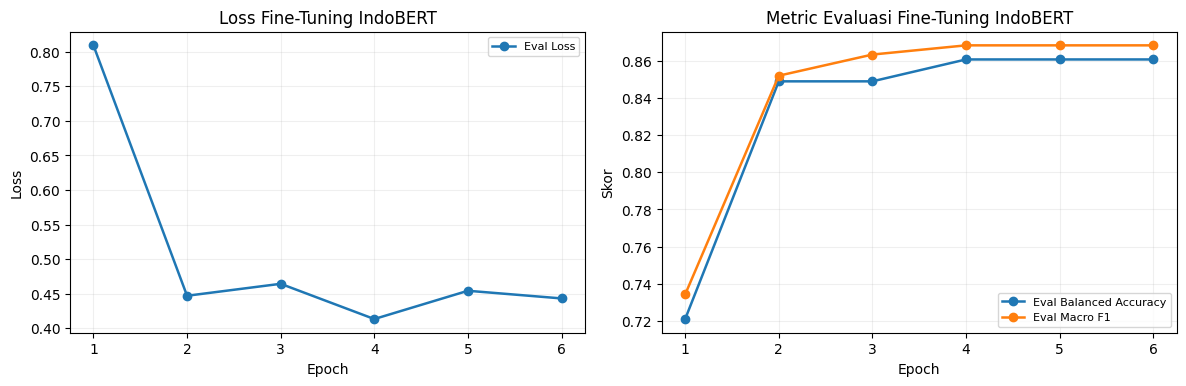

In [12]:
def checkpoint_step(path: Path) -> int:
    text = path.parent.name.replace("checkpoint-", "")
    return int(text) if text.isdigit() else -1


def latest_trainer_state_path(trainer_dir: Path):
    checkpoint_states = sorted(
        trainer_dir.glob("checkpoint-*/trainer_state.json"),
        key=checkpoint_step,
    )
    if checkpoint_states:
        return checkpoint_states[-1]

    root_state = trainer_dir / "trainer_state.json"
    return root_state if root_state.exists() else None


def numeric_history_rows(log_history: list[dict]) -> list[dict]:
    rows = []
    for item in log_history:
        row = {
            key: value
            for key, value in item.items()
            if isinstance(value, (int, float)) and not isinstance(value, bool)
        }
        if row:
            rows.append(row)
    return rows


def plot_history_lines(ax, rows: list[dict], metric_specs: list[tuple[str, str]], title: str, ylabel: str):
    x_label = "Epoch" if any("epoch" in row for row in rows) else "Step"
    plotted = False
    for metric_key, metric_label in metric_specs:
        points = []
        for fallback_index, row in enumerate(rows, start=1):
            if metric_key not in row:
                continue
            x_value = row.get("epoch", row.get("step", fallback_index))
            points.append((float(x_value), float(row[metric_key])))
        if not points:
            continue
        ax.plot(
            [point[0] for point in points],
            [point[1] for point in points],
            marker="o",
            linewidth=1.8,
            label=metric_label,
        )
        plotted = True

    if not plotted:
        ax.text(0.5, 0.5, "Log metric belum tersedia", ha="center", va="center")
        ax.set_axis_off()
        return

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
    ax.legend(loc="best", fontsize=8)


trainer_state_path = latest_trainer_state_path(EXPERIMENT_DIR / "trainer")
model_manifest_path = EXPERIMENT_DIR / "model_manifest.json"
model_manifest = None
if model_manifest_path.exists():
    model_manifest = json.loads(model_manifest_path.read_text(encoding=config.ENCODING))

if trainer_state_path is None and model_manifest is None:
    print("Artifact fine-tuning belum tersedia. Jalankan tahap train-indobert lebih dulu.")
else:
    if model_manifest is not None:
        display(
            pl.DataFrame(
                [
                    {
                        "model_dir": model_manifest.get("model_dir", ""),
                        "train_rows": int(model_manifest.get("train_rows", 0) or 0),
                        "internal_eval_rows": int(model_manifest.get("internal_eval_rows", 0) or 0),
                        "max_epochs": int((model_manifest.get("training_config") or {}).get("max_epochs", 0) or 0),
                        "learning_rate": float((model_manifest.get("training_config") or {}).get("learning_rate", 0.0) or 0.0),
                    }
                ]
            )
        )

    if trainer_state_path is None:
        print("trainer_state.json belum tersedia; menampilkan metrics manifest model.")
        manifest_metrics = model_manifest.get("metrics", {}) if model_manifest else {}
        metric_keys = ["eval_loss", "eval_balanced_accuracy", "eval_macro_f1"]
        available_metric_keys = [key for key in metric_keys if key in manifest_metrics]
        if available_metric_keys:
            fig, ax = plt.subplots(1, 1, figsize=(8, 4))
            values = [float(manifest_metrics[key]) for key in available_metric_keys]
            ax.bar(available_metric_keys, values, color="#4c78a8")
            ax.set_title("Metrics Fine-Tuning IndoBERT")
            ax.tick_params(axis="x", rotation=20)
            for index, value in enumerate(values):
                ax.text(index, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
            fig.tight_layout(pad=1.2)
            plt.show()
    else:
        trainer_state = json.loads(trainer_state_path.read_text(encoding=config.ENCODING))
        history_rows = numeric_history_rows(trainer_state.get("log_history", []))
        print(f"Trainer state: {trainer_state_path}")
        if not history_rows:
            print("Log history fine-tuning kosong.")
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            plot_history_lines(
                axes[0],
                history_rows,
                [("loss", "Train Loss"), ("eval_loss", "Eval Loss")],
                "Loss Fine-Tuning IndoBERT",
                "Loss",
            )
            plot_history_lines(
                axes[1],
                history_rows,
                [
                    ("eval_balanced_accuracy", "Eval Balanced Accuracy"),
                    ("eval_macro_f1", "Eval Macro F1"),
                ],
                "Metric Evaluasi Fine-Tuning IndoBERT",
                "Skor",
            )
            fig.tight_layout(pad=1.2)
            plt.show()


## 12. Sebaran Dataset dan Output Runtime


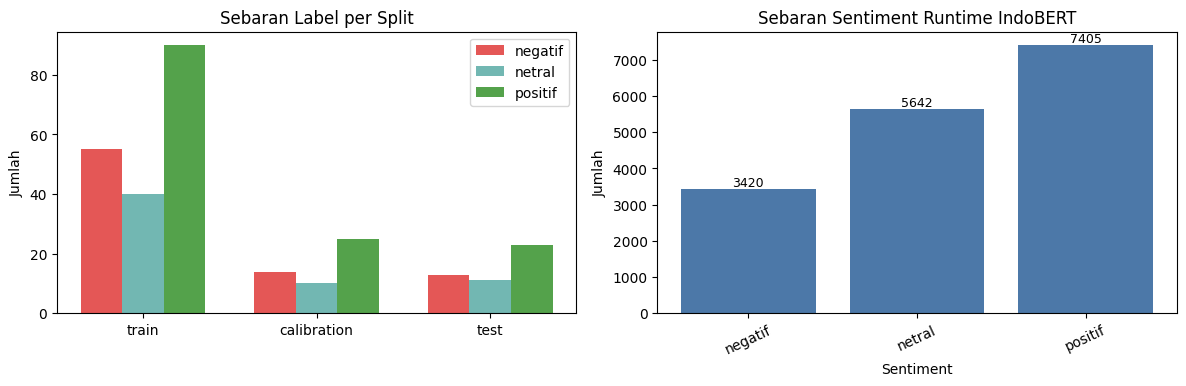

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
    split_df = pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH)
    grouped = split_df.group_by(["split", "sentiment_label"]).len().to_dicts()
    splits = ["train", "calibration", "test"]
    x = range(len(splits))
    width = 0.24
    colors = {"negatif": "#e45756", "netral": "#72b7b2", "positif": "#54a24b"}
    for offset, label in enumerate(LABEL_ORDER):
        values = [
            next(
                (
                    int(row["len"])
                    for row in grouped
                    if row["split"] == split and row["sentiment_label"] == label
                ),
                0,
            )
            for split in splits
        ]
        positions = [item + (offset - 1) * width for item in x]
        axes[0].bar(positions, values, width=width, label=label, color=colors[label])
    axes[0].set_title("Sebaran Label per Split")
    axes[0].set_xticks(list(x), splits)
    axes[0].set_ylabel("Jumlah")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Split dataset belum tersedia", ha="center", va="center")
    axes[0].set_axis_off()

if INDOBERT_PREDICTIONS_PATH.exists():
    predictions_df = pl.read_parquet(INDOBERT_PREDICTIONS_PATH)
    indobert_counts = counts_from_series(predictions_df["indobert_sentiment"].to_list())
    plot_count_bar(
        axes[1],
        indobert_counts,
        "Sebaran Sentiment Runtime IndoBERT",
        xlabel="Sentiment",
        order=LABEL_ORDER,
    )
else:
    axes[1].text(0.5, 0.5, "Runtime predictions belum tersedia", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout(pad=1.2)
plt.show()


## 13. Sebaran Dataset per Lokasi dan Metadata Runtime
Visualisasi ini memisahkan lokasi `Kalimantan Barat` sebagai fallback provinsi dari lokasi spesifik kabupaten/kota. Semua kabupaten/kota Kalbar dari `resources/wilayah/kabupaten.csv` tetap tampil, termasuk yang jumlahnya nol. Sumber data dipilih berurutan dari runtime predictions, training split, lalu raw candidate.


Sumber metadata: runtime predictions: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_indobert\indobert_nlp_predictions.parquet
Jumlah row: 16,467
Kolom sentiment: indobert_sentiment
Jumlah kabupaten/kota Kalbar ditampilkan: 14


kabupaten_kota,total,negatif,netral,positif
str,i64,i64,i64,i64
"""Sambas""",829,143,298,388
"""Bengkayang""",777,206,224,347
"""Landak""",545,97,191,257
"""Mempawah""",274,48,111,115
"""Sanggau""",571,124,180,267
…,…,…,…,…
"""Melawi""",116,27,28,61
"""Kayong Utara""",645,183,236,226
"""Kubu Raya""",798,99,279,420


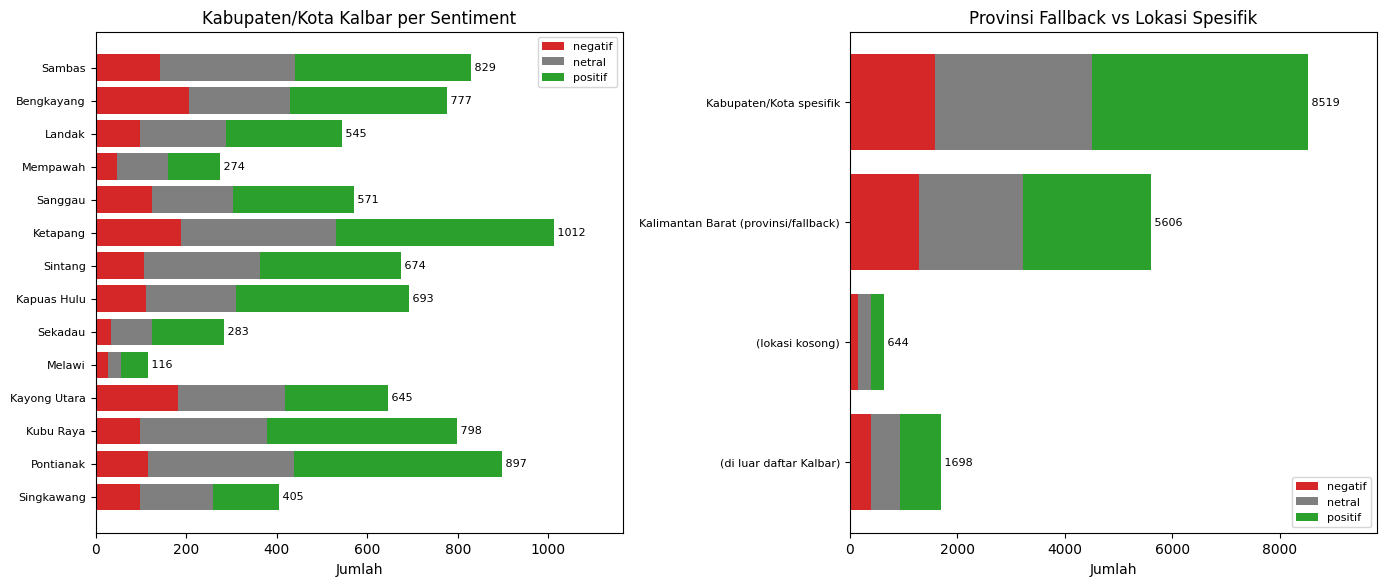

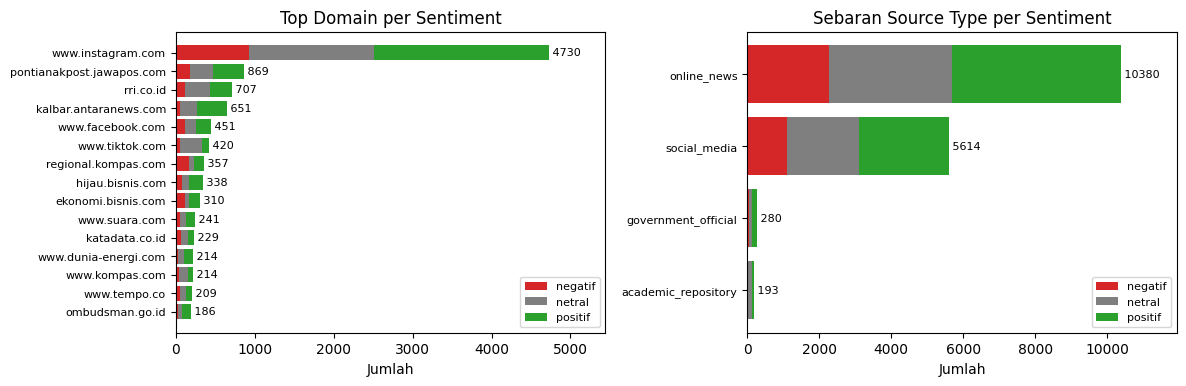

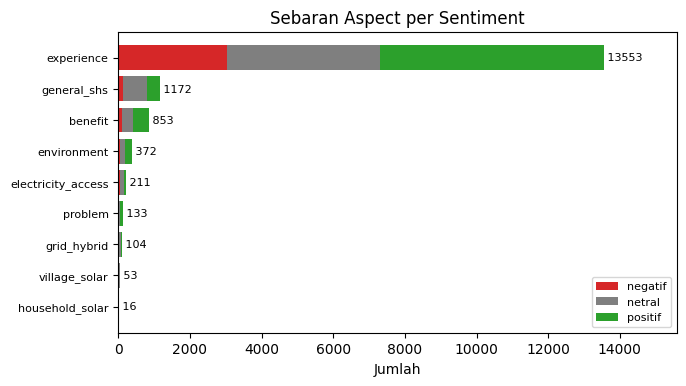

In [14]:
import csv
import re
from urllib.parse import urlparse


KALBAR_PROVINCE_LABEL = "Kalimantan Barat (provinsi/fallback)"
KALBAR_SPECIFIC_LABEL = "Kabupaten/Kota spesifik"
EMPTY_LOCATION_LABEL = "(lokasi kosong)"
OTHER_LOCATION_LABEL = "(di luar daftar Kalbar)"
KALBAR_PROVINCE_ALIASES = {"kalimantan barat", "kalbar"}


def load_metadata_distribution_df():
    if INDOBERT_PREDICTIONS_PATH.exists():
        return pl.read_parquet(INDOBERT_PREDICTIONS_PATH), f"runtime predictions: {INDOBERT_PREDICTIONS_PATH}"
    if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
        return pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH), f"training split: {config.TRAINING_DATASET_WITH_SPLIT_PATH}"
    if config.RAW_CANDIDATE_SCHEMA_PATH.exists():
        return pl.read_csv(config.RAW_CANDIDATE_SCHEMA_PATH, infer_schema_length=10_000, ignore_errors=True), f"raw candidate: {config.RAW_CANDIDATE_SCHEMA_PATH}"
    return None, ""


def read_csv_rows(path: Path) -> list[dict[str, str]]:
    if not path.exists():
        return []
    with path.open(encoding=config.ENCODING, newline="") as handle:
        return list(csv.DictReader(handle))


def canonical_kalbar_location_name(name: str) -> str:
    value = re.sub(r"\s+", " ", str(name or "").strip())
    value = re.sub(r"^(kabupaten|kab\.?|kota)\s+", "", value, flags=re.IGNORECASE)
    return value.title()


def load_kalbar_regency_names() -> list[str]:
    province_code = ""
    for row in read_csv_rows(config.RESOURCES / "wilayah" / "provinsi.csv"):
        if str(row.get("name") or "").casefold() == "kalimantan barat":
            province_code = str(row.get("code") or "").strip()
            break

    names = []
    seen = set()
    for row in read_csv_rows(config.RESOURCES / "wilayah" / "kabupaten.csv"):
        if str(row.get("parent_code") or "").strip() != province_code:
            continue
        name = canonical_kalbar_location_name(row.get("name") or "")
        key = name.casefold()
        if name and key not in seen:
            names.append(name)
            seen.add(key)
    return names


def raw_values_for_distribution(df, column):
    if column not in df.columns:
        return [""] * df.height
    return [str(value or "").strip() for value in df[column].to_list()]


def values_for_distribution(df, column):
    values = raw_values_for_distribution(df, column)
    return [value or "(kosong)" for value in values]


def sentiment_values_for_distribution(df):
    if "indobert_sentiment" in df.columns:
        values = values_for_distribution(df, "indobert_sentiment")
        if any(value in LABEL_ORDER for value in values):
            return values, "indobert_sentiment"
    if "bert_label" in df.columns:
        values = values_for_distribution(df, "bert_label")
        if any(value in LABEL_ORDER for value in values):
            return values, "bert_label"
    if "sentiment_label" in df.columns:
        values = [
            value if value in LABEL_ORDER else "(tanpa sentiment)"
            for value in values_for_distribution(df, "sentiment_label")
        ]
        return values, "sentiment_label"
    return ["(tanpa sentiment)"] * df.height, "(tanpa sentiment)"


def domain_values(df):
    if "raw_domain" in df.columns:
        values = values_for_distribution(df, "raw_domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "domain" in df.columns:
        values = values_for_distribution(df, "domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "source_url" not in df.columns:
        return []
    domains = []
    for url in df["source_url"].to_list():
        parsed = urlparse(str(url or ""))
        domains.append(parsed.netloc.lower() or "(kosong)")
    return domains


def sentiment_order(values):
    extras = sorted({value for value in values if value not in LABEL_ORDER})
    return [label for label in LABEL_ORDER if label in values] + extras


def grouped_counts_by_sentiment(category_values, sentiment_values):
    totals = {}
    grouped = {}
    for category, sentiment in zip(category_values, sentiment_values):
        category = str(category or "").strip() or "(kosong)"
        sentiment = str(sentiment or "").strip() or "(tanpa sentiment)"
        totals[category] = totals.get(category, 0) + 1
        grouped.setdefault(category, {})[sentiment] = grouped.setdefault(category, {}).get(sentiment, 0) + 1
    return totals, grouped


def plot_count_by_sentiment_barh(
    ax,
    category_values,
    sentiment_values,
    title,
    *,
    top_n=15,
    category_order=None,
):
    if not sentiment_values or (category_order is None and not category_values):
        ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
        ax.set_axis_off()
        return

    totals, grouped = grouped_counts_by_sentiment(category_values, sentiment_values)
    if category_order is None:
        if not totals:
            ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
            ax.set_axis_off()
            return
        labels = [label for label, _total in sorted(totals.items(), key=lambda item: (-item[1], item[0]))[:top_n]]
    else:
        labels = list(category_order)

    y_positions = list(range(len(labels)))
    left = [0] * len(labels)
    colors = {
        "negatif": "#d62728",
        "netral": "#7f7f7f",
        "positif": "#2ca02c",
        "(tanpa sentiment)": "#bdbdbd",
    }

    for sentiment in sentiment_order(sentiment_values):
        numbers = [grouped.get(label, {}).get(sentiment, 0) for label in labels]
        if not any(numbers):
            continue
        ax.barh(
            y_positions,
            numbers,
            left=left,
            label=sentiment,
            color=colors.get(sentiment, "#4c78a8"),
        )
        left = [current + value for current, value in zip(left, numbers)]

    ax.set_yticks(y_positions, labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Jumlah")
    ax.tick_params(axis="y", labelsize=8)
    max_total = max(left or [0])
    ax.set_xlim(0, max(1, max_total * 1.15))
    for index, total in enumerate(left):
        ax.text(total, index, f" {total}", va="center", fontsize=8)
    if any(left):
        ax.legend(loc="best", fontsize=8)


def kalbar_specific_location_values(location_values, regency_names):
    lookup = {name.casefold(): name for name in regency_names}
    values = []
    for value in location_values:
        canonical = canonical_kalbar_location_name(value)
        values.append(lookup.get(canonical.casefold(), OTHER_LOCATION_LABEL))
    return values


def kalbar_scope_values(location_values, regency_names):
    lookup = {name.casefold(): name for name in regency_names}
    values = []
    for value in location_values:
        canonical = canonical_kalbar_location_name(value)
        key = canonical.casefold()
        if not canonical:
            values.append(EMPTY_LOCATION_LABEL)
        elif key in lookup:
            values.append(KALBAR_SPECIFIC_LABEL)
        elif key in KALBAR_PROVINCE_ALIASES:
            values.append(KALBAR_PROVINCE_LABEL)
        else:
            values.append(OTHER_LOCATION_LABEL)
    return values


metadata_df, metadata_source = load_metadata_distribution_df()
if metadata_df is None:
    print("Dataset metadata belum tersedia. Jalankan build raw candidate atau runtime IndoBERT lebih dulu.")
else:
    sentiment_values, sentiment_column = sentiment_values_for_distribution(metadata_df)
    location_values = raw_values_for_distribution(metadata_df, "location")
    kalbar_regency_names = load_kalbar_regency_names()
    specific_location_values = kalbar_specific_location_values(location_values, kalbar_regency_names)
    scope_location_values = kalbar_scope_values(location_values, kalbar_regency_names)

    print(f"Sumber metadata: {metadata_source}")
    print(f"Jumlah row: {metadata_df.height:,}")
    print(f"Kolom sentiment: {sentiment_column}")
    print(f"Jumlah kabupaten/kota Kalbar ditampilkan: {len(kalbar_regency_names)}")

    specific_totals, specific_grouped = grouped_counts_by_sentiment(specific_location_values, sentiment_values)
    display(
        pl.DataFrame(
            [
                {
                    "kabupaten_kota": location,
                    "total": int(specific_totals.get(location, 0)),
                    "negatif": int(specific_grouped.get(location, {}).get("negatif", 0)),
                    "netral": int(specific_grouped.get(location, {}).get("netral", 0)),
                    "positif": int(specific_grouped.get(location, {}).get("positif", 0)),
                }
                for location in kalbar_regency_names
            ]
        )
    )

    fig_height = max(6, len(kalbar_regency_names) * 0.42)
    fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))
    plot_count_by_sentiment_barh(
        axes[0],
        specific_location_values,
        sentiment_values,
        "Kabupaten/Kota Kalbar per Sentiment",
        category_order=kalbar_regency_names,
    )
    plot_count_by_sentiment_barh(
        axes[1],
        scope_location_values,
        sentiment_values,
        "Provinsi Fallback vs Lokasi Spesifik",
        category_order=[KALBAR_SPECIFIC_LABEL, KALBAR_PROVINCE_LABEL, EMPTY_LOCATION_LABEL, OTHER_LOCATION_LABEL],
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_count_by_sentiment_barh(
        axes[0],
        domain_values(metadata_df),
        sentiment_values,
        "Top Domain per Sentiment",
        top_n=15,
    )
    plot_count_by_sentiment_barh(
        axes[1],
        values_for_distribution(metadata_df, "source_type"),
        sentiment_values,
        "Sebaran Source Type per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    plot_count_by_sentiment_barh(
        ax,
        values_for_distribution(metadata_df, "aspect"),
        sentiment_values,
        "Sebaran Aspect per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.show()


## 14. Confidence, Margin, dan Entropy IndoBERT


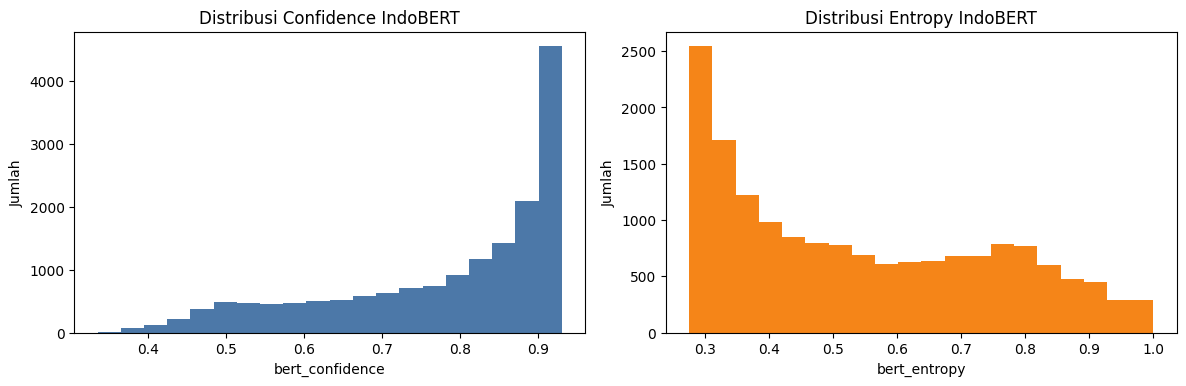

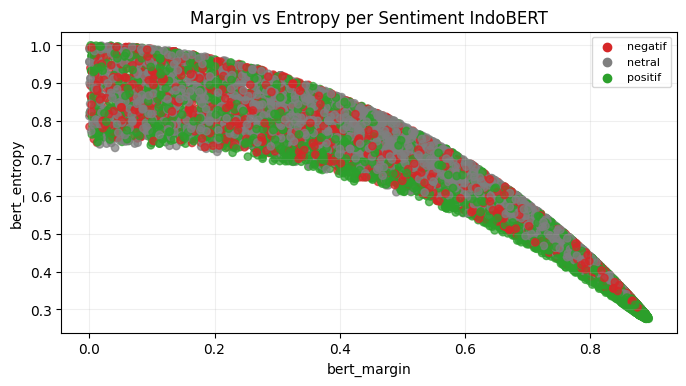

In [15]:
if INDOBERT_PREDICTIONS_PATH.exists():
    predictions_df = pl.read_parquet(INDOBERT_PREDICTIONS_PATH)

    required_columns = [
        "bert_confidence",
        "bert_margin",
        "bert_entropy",
        "indobert_sentiment",
    ]
    missing_columns = [column for column in required_columns if column not in predictions_df.columns]

    if missing_columns:
        print(f"Kolom visual IndoBERT belum tersedia: {missing_columns}")
    else:
        sentiment_colors = {
            "negatif": "#d62728",
            "netral": "#7f7f7f",
            "positif": "#2ca02c",
        }
        confidence_values = predictions_df["bert_confidence"].cast(pl.Float64).to_list()
        margin_values = predictions_df["bert_margin"].cast(pl.Float64).to_list()
        entropy_values = predictions_df["bert_entropy"].cast(pl.Float64).to_list()
        sentiment_labels = predictions_df["indobert_sentiment"].to_list()
        point_colors = [sentiment_colors.get(label, "#333333") for label in sentiment_labels]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(confidence_values, bins=20, color="#4c78a8")
        axes[0].set_title("Distribusi Confidence IndoBERT")
        axes[0].set_xlabel("bert_confidence")
        axes[0].set_ylabel("Jumlah")

        axes[1].hist(entropy_values, bins=20, color="#f58518")
        axes[1].set_title("Distribusi Entropy IndoBERT")
        axes[1].set_xlabel("bert_entropy")
        axes[1].set_ylabel("Jumlah")
        fig.tight_layout(pad=1.2)
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(7, 4))
        ax.scatter(
            margin_values,
            entropy_values,
            c=point_colors,
            alpha=0.72,
            s=28,
        )
        ax.set_title("Margin vs Entropy per Sentiment IndoBERT")
        ax.set_xlabel("bert_margin")
        ax.set_ylabel("bert_entropy")
        ax.grid(alpha=0.2)
        for label, color in sentiment_colors.items():
            ax.scatter([], [], c=color, label=label, s=36)
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout(pad=1.2)
        plt.show()
else:
    print("Prediksi runtime belum tersedia. Jalankan tahap runtime IndoBERT lebih dulu.")
